Import thư viện

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, f1_score, roc_curve

sns.set_theme(style="whitegrid")

Đọc dữ liệu & Chọn lọc đặc trưng (Feature Selection)
Lọc bỏ các cột làm trơn (rolling mean/std), chỉ giữ lại tín hiệu độ lệch (z-score, diff).

In [2]:
# --- Tự động dò đường dẫn ---
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    PROJECT_ROOT = os.path.dirname(current_dir)
else:
    PROJECT_ROOT = current_dir

TRAIN_PATH = os.path.join(PROJECT_ROOT, "data", "features", "T1_train.csv")
TEST_PATH = os.path.join(PROJECT_ROOT, "data", "features", "T1_test.csv")

df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

# --- Tối ưu Đặc trưng (Feature Selection) ---
features = [col for col in df_train.columns if ('zscore' in col) or ('diff' in col)]

X_train = df_train[features].values
X_test = df_test[features].values

print(f"Số lượng features dùng để train: {len(features)}")
print("Danh sách features:", features)

Số lượng features dùng để train: 6
Danh sách features: ['LV ActivePower (kW)_zscore', 'Wind Speed (m/s)_zscore', 'Theoretical_Power_Curve (KWh)_zscore', 'LV ActivePower (kW)_diff_1', 'Wind Speed (m/s)_diff_1', 'Theoretical_Power_Curve (KWh)_diff_1']


Tạo Nhãn giả (Pseudo-labels) bằng Vật lý
Dùng phần dư công suất (Power Residual) để đánh dấu bất thường.

In [3]:
# Tính giá trị trung bình và độ lệch chuẩn của phần dư công suất từ tập Train
mean_val = df_train['power_residual'].mean()
std_val = df_train['power_residual'].std()

# Xác định ngưỡng trên và ngưỡng dưới 
lower_bound = mean_val - 3 * std_val
upper_bound = mean_val + 3 * std_val

# Tạo nhãn giả cho tập Test (1: Bất thường, 0: Bình thường)
# Bắt bất thường nếu phần dư rớt xuống dưới ngưỡng dưới HOẶC vượt quá ngưỡng trên
y_test_pseudo = ((df_test['power_residual'] < lower_bound) | 
                 (df_test['power_residual'] > upper_bound)).astype(int)

# Thống kê kết quả
anomalies_count = y_test_pseudo.sum()
print(f"Giá trị trung bình phần dư (Train): {mean_val:.2f}")
print(f"Độ lệch chuẩn (Train): {std_val:.2f}")
print(f"Ngưỡng xác định bất thường: Dưới {lower_bound:.2f} HOẶC Trên {upper_bound:.2f}")
print(f"Số lượng bất thường trong tập test: {anomalies_count} ({anomalies_count/len(y_test_pseudo)*100:.2f}%)")

Giá trị trung bình phần dư (Train): -0.00
Độ lệch chuẩn (Train): 1.00
Ngưỡng xác định bất thường: Dưới -3.00 HOẶC Trên 3.00
Số lượng bất thường trong tập test: 207 (1.31%)


In [4]:
# Giả định tỷ lệ bất thường là 1.5% 
CONTAMINATION = 0.015

print("🚀 BẮT ĐẦU CUỘC ĐUA 5 MÔ HÌNH KHÔNG GIÁM SÁT...\n")

# 1. Isolation Forest
print("[1/5] Đang train Isolation Forest...")
iforest = IsolationForest(n_estimators=150, contamination=CONTAMINATION, random_state=42, n_jobs=-1)
iforest.fit(X_train)
scores_iforest = -iforest.score_samples(X_test)
preds_iforest = np.where(iforest.predict(X_test) == -1, 1, 0)

# 2. Local Outlier Factor (LOF)
print("[2/5] Đang train Local Outlier Factor...")
lof = LocalOutlierFactor(n_neighbors=35, contamination=CONTAMINATION, novelty=True, n_jobs=-1)
lof.fit(X_train)
scores_lof = -lof.score_samples(X_test)
preds_lof = np.where(lof.predict(X_test) == -1, 1, 0)

# 3. One-Class SVM
# Lưu ý: OCSVM có thể chạy hơi lâu (khoảng 1-2 phút) do độ phức tạp O(n^2)
print("[3/5] Đang train One-Class SVM (sẽ mất khoảng 1-2 phút)...")
ocsvm = OneClassSVM(nu=CONTAMINATION, kernel="rbf", gamma="scale")
ocsvm.fit(X_train)
scores_ocsvm = -ocsvm.score_samples(X_test)
preds_ocsvm = np.where(ocsvm.predict(X_test) == -1, 1, 0)

# 4. Gaussian Mixture Model (GMM)
print("[4/5] Đang train Gaussian Mixture Model...")
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
gmm.fit(X_train)
# GMM chấm điểm log-likelihood (càng thấp càng bất thường, nên ta đổi dấu)
scores_gmm = -gmm.score_samples(X_test)
# Tìm ngưỡng cắt cho GMM dựa trên contamination
threshold_gmm = np.percentile(scores_gmm, 100 * (1 - CONTAMINATION))
preds_gmm = (scores_gmm > threshold_gmm).astype(int)

# 5. Hybrid Model: PCA + Isolation Forest
print("[5/5] Đang train Hybrid Model (PCA + Isolation Forest)...")
hybrid_model = Pipeline([
    ('pca', PCA(n_components=0.95, random_state=42)), # Giữ lại 95% phương sai, loại bỏ nhiễu
    ('iforest', IsolationForest(n_estimators=150, contamination=CONTAMINATION, random_state=42, n_jobs=-1))
])
hybrid_model.fit(X_train)
# Trick để lấy điểm từ Pipeline
X_test_pca = hybrid_model.named_steps['pca'].transform(X_test)
scores_hybrid = -hybrid_model.named_steps['iforest'].score_samples(X_test_pca)
preds_hybrid = np.where(hybrid_model.predict(X_test) == -1, 1, 0)

🚀 BẮT ĐẦU CUỘC ĐUA 5 MÔ HÌNH KHÔNG GIÁM SÁT...

[1/5] Đang train Isolation Forest...
[2/5] Đang train Local Outlier Factor...
[3/5] Đang train One-Class SVM (sẽ mất khoảng 1-2 phút)...
[4/5] Đang train Gaussian Mixture Model...
[5/5] Đang train Hybrid Model (PCA + Isolation Forest)...



🏆 TỔNG KẾT ĐIỂM SỐ (Dựa trên Pseudo-label):
          Mô hình  Pseudo-AUC  Pseudo-F1
              GMM    0.931211   0.157658
 Isolation Forest    0.881257   0.037037
Hybrid (PCA + IF)    0.761193   0.107527
              LOF    0.745434   0.084541
    One-Class SVM    0.502334   0.169666


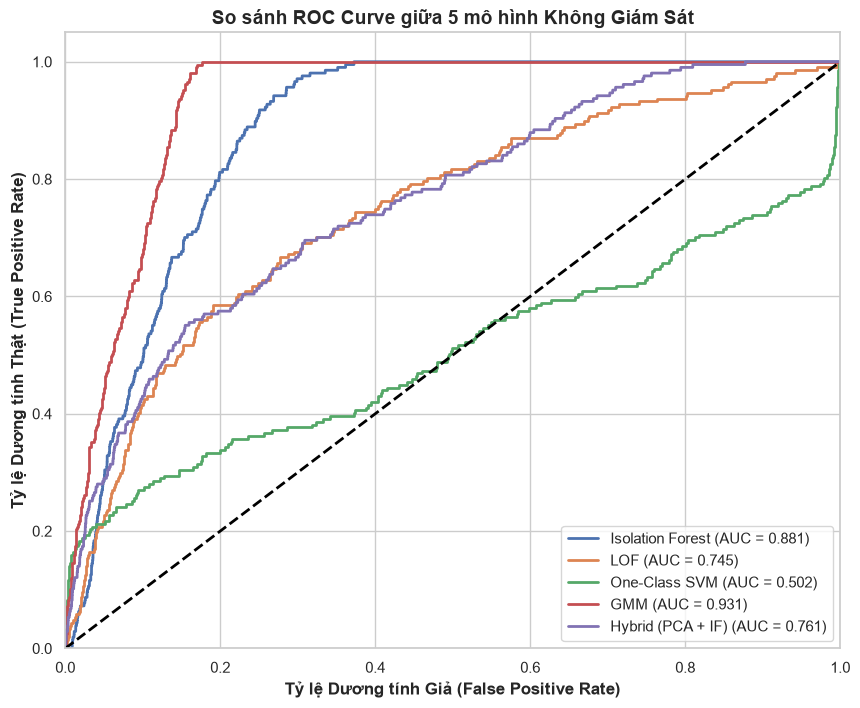

In [5]:
print("\n🏆 TỔNG KẾT ĐIỂM SỐ (Dựa trên Pseudo-label):")
models = {
    "Isolation Forest": (preds_iforest, scores_iforest),
    "LOF": (preds_lof, scores_lof),
    "One-Class SVM": (preds_ocsvm, scores_ocsvm),
    "GMM": (preds_gmm, scores_gmm),
    "Hybrid (PCA + IF)": (preds_hybrid, scores_hybrid)
}

results = []
for name, (preds, scores) in models.items():
    auc = roc_auc_score(y_test_pseudo, scores)
    f1 = f1_score(y_test_pseudo, preds)
    results.append({"Mô hình": name, "Pseudo-AUC": auc, "Pseudo-F1": f1})

df_results = pd.DataFrame(results).sort_values(by="Pseudo-AUC", ascending=False)
try:
    print(df_results.to_markdown(index=False))
except Exception:
    # Fallback if tabulate is not installed
    print(df_results.to_string(index=False))

# Vẽ biểu đồ đường ROC Curve để so sánh sức mạnh
plt.figure(figsize=(10, 8))
for name, (_, scores) in models.items():
    fpr, tpr, _ = roc_curve(y_test_pseudo, scores)
    auc_score = roc_auc_score(y_test_pseudo, scores)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)', fontweight='bold')
plt.ylabel('Tỷ lệ Dương tính Thật (True Positive Rate)', fontweight='bold')
plt.title('So sánh ROC Curve giữa 5 mô hình Không Giám Sát', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# PHƯỚNG ÁN LOCAL (TỰ ĐỘNG LƯU MÔ HÌNH VÀ ĐẨY LÊN S3)
# import numpy as np
# import joblib
# import tarfile
# import boto3
# import os

# X_full = np.concatenate([X_train, X_test], axis=0)

# print("Đang huấn luyện mô hình GMM cuối cùng trên toàn bộ dữ liệu...")
# final_model = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
# final_model.fit(X_full)

# # Lưu mô hình (Model Artifact)
# model_path = "model.joblib"
# joblib.dump(final_model, model_path)
# print(f"✅ [1/3] Đã lưu mô hình thành công tại: {model_path}")

# # TỰ ĐỘNG ĐÓNG GÓI CHUẨN SAGEMAKER
# tar_name = "model.tar.gz"

# with tarfile.open(tar_name, "w:gz") as tar:
#     tar.add(model_path, arcname=os.path.basename(model_path))
# print(f"📦 [2/3] Đã nén chuẩn SageMaker thành công: {tar_name}")

# # TỰ ĐỘNG PUSH LÊN AWS S3
# bucket_name = "amznce23"  
# s3_key = f"output/{tar_name}"

# try:
#     print("☁️ Đang đồng bộ lên đám mây AWS...")
#     s3 = boto3.client('s3')
#     s3.upload_file(tar_name, bucket_name, s3_key)
#     print(f"🚀 [3/3] NHIỆM VỤ HOÀN TẤT! Mô hình đã sẵn sàng tại: s3://{bucket_name}/{s3_key}")
# except Exception as e:
#     print(f"❌ Có lỗi khi đẩy lên S3. Em kiểm tra lại mạng hoặc quyền IAM nhé. Chi tiết: {e}")

Đang huấn luyện mô hình GMM cuối cùng trên toàn bộ dữ liệu...
✅ [1/3] Đã lưu mô hình thành công tại: model.joblib
📦 [2/3] Đã nén chuẩn SageMaker thành công: model.tar.gz
☁️ Đang đồng bộ lên đám mây AWS...
🚀 [3/3] NHIỆM VỤ HOÀN TẤT! Mô hình đã sẵn sàng tại: s3://amznce23/output/model.tar.gz


In [2]:
import joblib
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 1. Tải mô hình đã train trên AWS (Nhớ đảm bảo em đã tải và giải nén model.joblib vào thư mục models/)
cloud_model = joblib.load('models/model.joblib')
print("☁️ Đã load thành công mô hình GMM huấn luyện từ AWS SageMaker!")

# 2. Lấy điểm số bất thường (Anomaly Score) từ tập Test
# GMM trả về log-likelihood (điểm càng thấp -> càng bất thường). 
# Ta nhân với -1 để đảo ngược lại: điểm càng cao -> càng bất thường (giống chuẩn chung)
gmm_scores = -cloud_model.score_samples(X_test)

# 3. Tính toán độ chính xác AUC
auc_score = roc_auc_score(y_test_pseudo, gmm_scores)
print(f"🎯 Điểm số AUC của Cloud Model: {auc_score:.3f}")

# 4. Vẽ biểu đồ ROC Curve để báo cáo
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, color='darkorange', label=f"AWS SageMaker GMM (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)', fontweight='bold')
plt.ylabel('Tỷ lệ Dương tính Thật (True Positive Rate)', fontweight='bold')
plt.title('Biểu đồ ROC - Đánh giá mô hình MLOps trên Cloud', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'models/model.joblib'